In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time
import gc

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training:", x_train.shape)
print("Testing :", x_test.shape)

Training: (50000, 32, 32, 3)
Testing : (10000, 32, 32, 3)


In [3]:
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

y_train = y_train.astype(np.int32)
y_test = y_test.astype(np.int32)

print("Data type:", x_train.dtype)
print("Range:", x_train.min(), "to", x_train.max())

Data type: float32
Range: 0.0 to 1.0


In [4]:
IMG_SIZE = 224
BATCH_SIZE = 16

def data_generator(images, labels, batch_size=16):
    num_samples = len(images)

    while True:
        indices = np.random.permutation(num_samples)

        for start in range(0, num_samples, batch_size):
            batch_indices = indices[start:start + batch_size]

            batch_images = images[batch_indices]
            batch_labels = labels[batch_indices]

            # Resize only this small batch
            batch_images = tf.image.resize(
                batch_images,
                (IMG_SIZE, IMG_SIZE)
            )

            yield batch_images, batch_labels

In [5]:
train_generator = data_generator(
    x_train,
    y_train,
    BATCH_SIZE
)

test_generator = data_generator(
    x_test,
    y_test,
    BATCH_SIZE
)

print("Generators created successfully.")

Generators created successfully.


In [6]:
images, labels = next(train_generator)

print("Batch images:", images.shape)
print("Batch labels:", labels.shape)
print("Image dtype:", images.dtype)

Batch images: (16, 224, 224, 3)
Batch labels: (16, 1)
Image dtype: <dtype: 'float32'>


In [7]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
steps_per_epoch = len(x_train) // BATCH_SIZE
validation_steps = len(x_test) // BATCH_SIZE

print("Steps per epoch:", steps_per_epoch)
print("Validation steps:", validation_steps)

Steps per epoch: 3125
Validation steps: 625


In [9]:
start_time = time.time()

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    validation_data=test_generator,
    validation_steps=validation_steps,
    epochs=10,
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4593s 1s/step - accuracy: 0.1545 - loss: 2.2483 - val_accuracy: 0.1697 - val_loss: 2.1624
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3590s 1s/step - accuracy: 0.2219 - loss: 2.0716 - val_accuracy: 0.2411 - val_loss: 2.0357
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3403s 1s/step - accuracy: 0.2425 - loss: 2.0091 - val_accuracy: 0.2324 - val_loss: 2.0387
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3441s 1s/step - accuracy: 0.2505 - loss: 1.9788 - val_accuracy: 0.2658 - val_loss: 1.9434
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4050s 1s/step - accuracy: 0.2568 - loss: 1.9533 - val_accuracy: 0.2717 - val_loss: 1.9223
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 4509s 1s/step - accuracy: 0.2601 - loss: 1.9363 - val_accuracy: 0.2761 - val_loss: 1.9134
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3575s 1s/step - accuracy: 0.2712 - loss: 1.9183 - val_accuracy: 0.2874 - val_loss: 1.8938
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 3438s 1s/step - accuracy: 0.2753 -

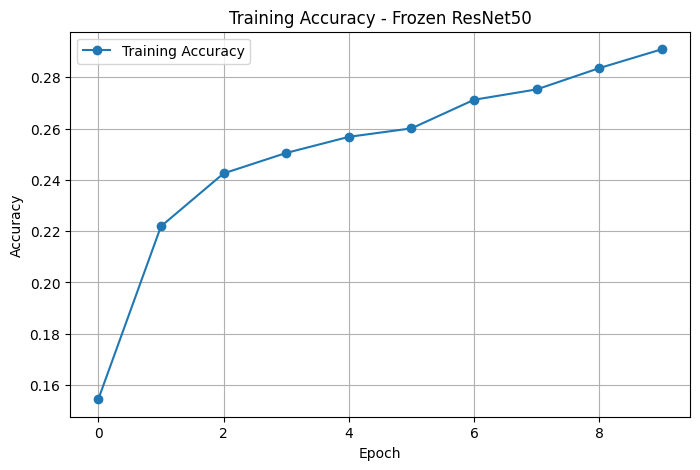

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy - Frozen ResNet50")
plt.legend()
plt.grid(True)

plt.savefig(
    "Figures/training_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

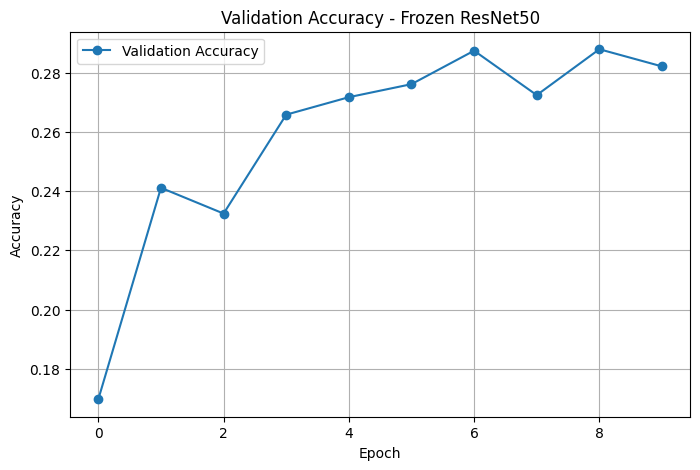

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy - Frozen ResNet50")
plt.legend()
plt.grid(True)

plt.savefig(
    "Figures/validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

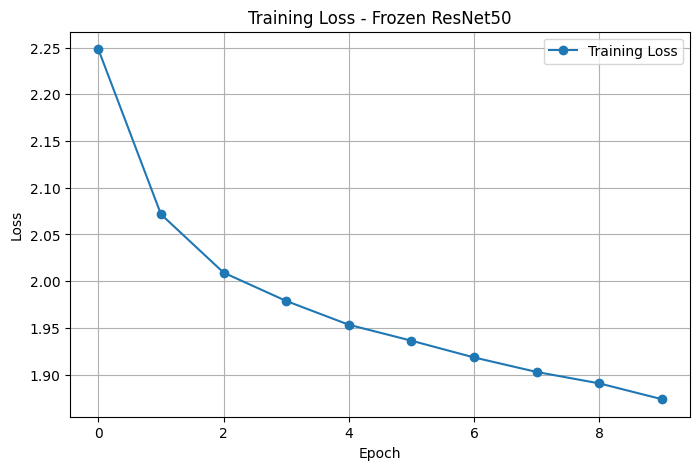

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss - Frozen ResNet50")
plt.legend()
plt.grid(True)

plt.savefig(
    "Figures/training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

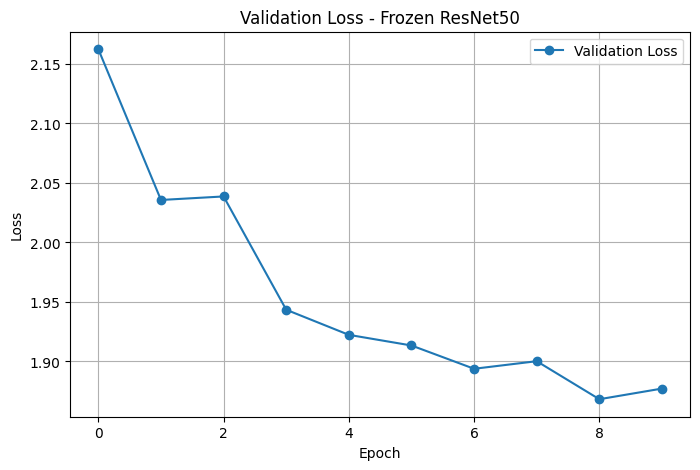

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss - Frozen ResNet50")
plt.legend()
plt.grid(True)

plt.savefig(
    "Figures/validation_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.2909199893474579
Final Validation Accuracy: 0.28209999203681946
Final Training Loss: 1.8736211061477661
Final Validation Loss: 1.8771966695785522
